In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
trades = pd.read_csv("datasets/historical_data.csv")
sentiment = pd.read_csv("datasets/fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [21]:
trades.columns = trades.columns.str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.lower().str.replace(" ", "_")

In [22]:
trades['timestamp'] = pd.to_numeric(trades['timestamp'], errors='coerce')
trades['datetime'] = pd.to_datetime(trades['timestamp'], unit='ms')
trades['date'] = trades['datetime'].dt.date

In [23]:
sentiment['timestamp'] = pd.to_numeric(sentiment['timestamp'], errors='coerce')
sentiment['datetime'] = pd.to_datetime(sentiment['timestamp'], unit='s')
sentiment['date'] = sentiment['datetime'].dt.date

In [24]:
numeric_cols = ['execution_price', 'size_usd', 'closed_pnl', 'fee']
for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors='coerce')

In [25]:
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

In [26]:
merged = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

print("Merged Shape:", merged.shape)

Merged Shape: (211224, 19)


In [27]:
avg_pnl = merged.groupby('classification')['closed_pnl'].mean()
print("\nAverage PnL by Sentiment:\n", avg_pnl)


Average PnL by Sentiment:
 classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: closed_pnl, dtype: float64


In [28]:
total_pnl = merged.groupby('classification')['closed_pnl'].sum()
print("\nTotal PnL by Sentiment:\n", total_pnl)


Total PnL by Sentiment:
 classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            3.189617e+06
Neutral          1.587424e+05
Name: closed_pnl, dtype: float64


In [29]:
trade_count = merged['classification'].value_counts()
print("\nTrade Count:\n", trade_count)


Trade Count:
 classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [30]:
buy_sell = pd.crosstab(merged['side'], merged['classification'])
print("\nBuy vs Sell:\n", buy_sell)


Buy vs Sell:
 classification  Extreme Greed   Fear  Greed  Neutral
side                                                
BUY                      3371  66081  15421     3505
SELL                     3591  67790  20868     3636


In [31]:
merged['is_profit'] = merged['closed_pnl'] > 0
profit_ratio = pd.crosstab(merged['classification'], merged['is_profit'], normalize='index')
print("\nProfitability Ratio:\n", profit_ratio)


Profitability Ratio:
 is_profit          False     True 
classification                    
Extreme Greed   0.509911  0.490089
Fear            0.584854  0.415146
Greed           0.553529  0.446471
Neutral         0.682818  0.317182


In [32]:
sns.set(style="whitegrid")

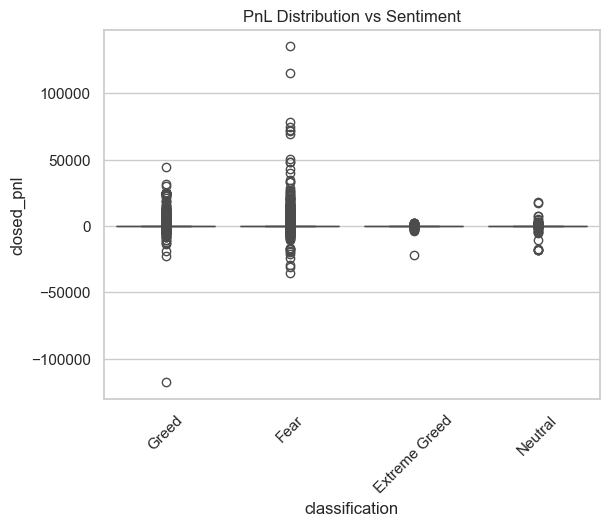

In [33]:
plt.figure()
sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.title("PnL Distribution vs Sentiment")
plt.xticks(rotation=45)
plt.show()

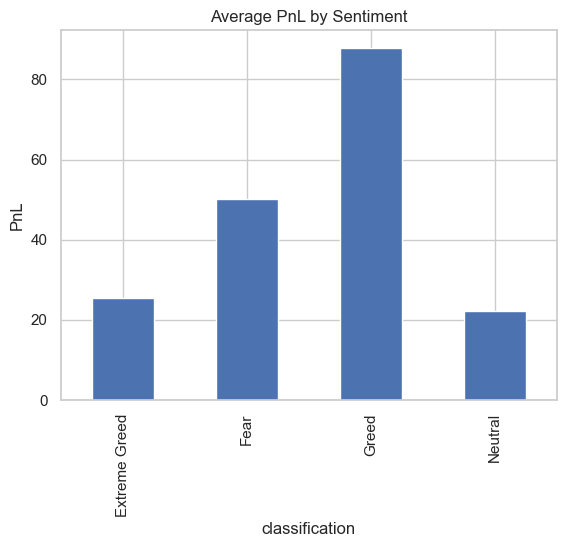

In [34]:
plt.figure()
avg_pnl.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("PnL")
plt.show()

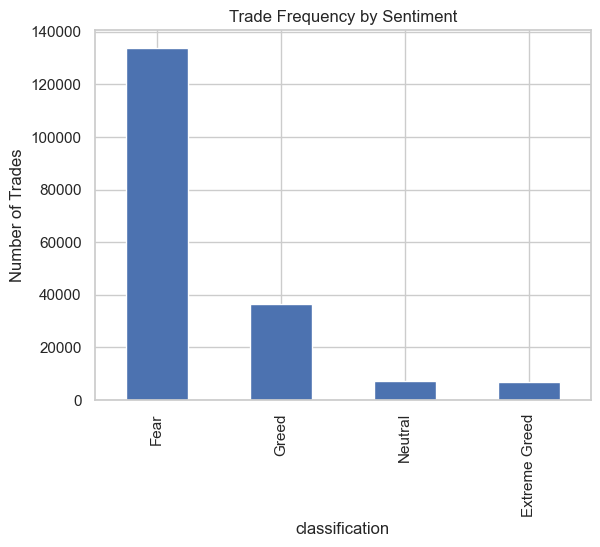

In [35]:
plt.figure()
trade_count.plot(kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [36]:
top_traders = merged.groupby('account')['closed_pnl'].sum().sort_values(ascending=False).head(10)

top_accounts = top_traders.index
filtered = merged[merged['account'].isin(top_accounts)]

pd.crosstab(filtered['account'], filtered['classification'])

classification,Extreme Greed,Fear,Greed,Neutral
account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,0,3356,462,0
0x430f09841d65beb3f27765503d0f850b8bce7713,88,671,43,249
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,0,3806,328,0
0x513b8629fe877bb581bf244e326a047b249c4ff1,0,5777,223,0
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,0,932,202,0
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,0,939,419,0
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3041,4885,1016,6
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3076,7380,2311,1643
0xbaaaf6571ab7d571043ff1e313a9609a10637864,0,21190,0,0


# 🔍 Key Insights

## What We Found

Market sentiment has a strong impact on trader profitability and behavior.

### 🎯 Sentiment Drives Profitability
- Traders achieve the highest average profit during **Greed phases (~88 PnL)**.
- Profitability is moderate during **Fear (~50 PnL)** and significantly lower during **Neutral (~22 PnL)** and **Extreme Greed (~25 PnL)**.
- This suggests that normal Greed conditions are more favorable than extreme market conditions.

### 📊 Clear Trading Patterns
- Trading performance varies significantly across sentiment phases, indicating that market mood influences decision-making.
- Lower profitability during Extreme Greed suggests possible overconfidence and poor trade execution.

### 💡 The Winning Edge
- The best trading opportunities appear during **Greed phases**, where market momentum is strong.
- However, performance drops in Extreme Greed, indicating that excessive optimism can negatively impact results.
- Traders who avoid emotional extremes and trade strategically during stable Greed conditions tend to perform better.

## 🚀 Bottom Line

1. Market sentiment is a key factor in trading success  
2. **Greed phases offer the best profit opportunities**, but Extreme Greed should be approached cautiously  
3. Avoid overconfidence—data shows that extreme market conditions reduce profitability  